In [1]:
from mlxtend.classifier import OneRClassifier
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from utils import column_type_split
from utils.evaluation import evaluate_pipeline

In [2]:
df = pd.read_csv("../data/train_clear.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
def get_pipeline(X: pd.DataFrame) -> Pipeline:
    columns = column_type_split(X)
    return Pipeline(
    [
        (
            "preprocess",
            ColumnTransformer(
                [
                    (
                        "ordinal",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                            dtype=np.int64,
                        ),
                        columns.categorical,
                    ),
                    (
                        "kbins",
                        KBinsDiscretizer(
                            n_bins=20,
                            encode="ordinal",
                            strategy="quantile",
                            quantile_method="linear",  # pyright: ignore[reportCallIssue]
                        ),
                        columns.numeric,
                    ),
                ],
                remainder="passthrough",
            ),
        ),
        ("onerule", OneRClassifier()),
    ]
)

In [5]:
pipeline = get_pipeline(X)

Модель OneRClassifier
F1-macro: 0.334 ± 0.003
F1-weighted: 0.448 ± 0.002


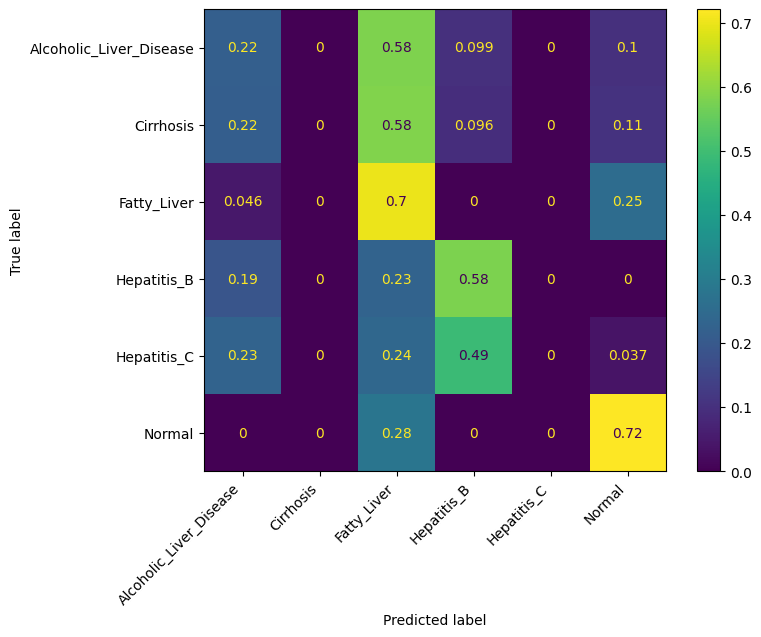

In [6]:
winning_features = evaluate_pipeline(pipeline, X, y, additional="feature_idx_")

In [7]:
preprocessor = pipeline.named_steps['preprocess']
feature_names = preprocessor.get_feature_names_out()

feature_names[winning_features]

array(['kbins__ALT', 'kbins__ALT', 'kbins__ALT', 'kbins__ALT',
       'kbins__ALT'], dtype=object)

In [8]:
pipeline_wo_alt = get_pipeline(X.drop(columns=["ALT"]))

Модель OneRClassifier
F1-macro: 0.310 ± 0.004
F1-weighted: 0.438 ± 0.004


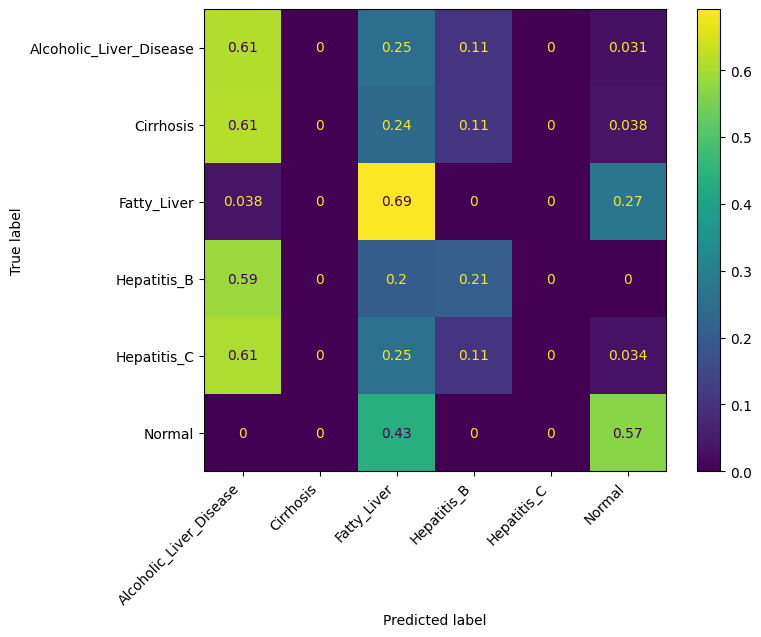

In [9]:
winning_features = evaluate_pipeline(pipeline_wo_alt, X.drop(columns=["ALT"]), y, additional="feature_idx_")

In [10]:
preprocessor = pipeline_wo_alt.named_steps['preprocess']
feature_names = preprocessor.get_feature_names_out()

feature_names[winning_features]

array(['kbins__AST', 'kbins__AST', 'kbins__AST', 'kbins__AST',
       'kbins__AST'], dtype=object)

Модель выбрала признак ALT (один из важнейших ферментов печени) как наилучший для определения болезни\
При его отсутствии модель выбрала AST - второй из важнейших ферментов печени

Полученные результаты подтверждают, что основные ферменты печени ALT и AST существенно меняются при разных состояниях печени\
Низкая точность модели показывает, что сфера болезней печени достаточно сложная и не может быть полноценно предсказана по всего одному признаку